# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rdata
import networkx as nx

# Read data

In [3]:
%%capture

data_name = 'bifurcating'; num_metacells = 30; n_trj = 2
# data_name = 'trifurcating'; num_metacells = 30; n_trj = 3
# data_name = 'double_bifurcating'; num_metacells = 20; n_trj = 3

data = rdata.read_rds(f'./Datasets/{data_name}/dataset.rds')
n_cells, n_genes = data['expression'].Dim

def extract_layer(data, layer_name):
    layer = np.zeros(data[layer_name].Dim)
    j = 0
    for iter, i, x in zip(np.arange(len(data[layer_name].i)), data[layer_name].i, data[layer_name].x):
        layer[i, j] = x
        if iter == data[layer_name].p[j+1]: j += 1
    return layer

expressions = extract_layer(data, 'expression')
velocities = extract_layer(data, 'rna_velocity')
spliced = extract_layer(data, 'counts_spliced')
unspliced = extract_layer(data, 'counts_unspliced')

initial = np.array([list(data['milestone_ids']).index(ms) for ms in data['progressions']['from']])
colors = plt.colormaps['Set1'](initial)

# Extract topological info of differentiation tree

In [4]:
milestone_lengths = [len([ms for ms in data['progressions']['from'] if ms==id]) for id in data['milestone_ids']]
print(data['milestone_ids'])
print(milestone_lengths)
initial_pseudotime = np.zeros_like(milestone_lengths)
id2i = {id:i for i, id in enumerate(data['milestone_ids'])}
for i in range(1, len(id2i)):
    id_from = data['milestone_network'].at[i, 'from']
    id_to = data['milestone_network'].at[i, 'to']
    initial_pseudotime[id2i[id_to]] = initial_pseudotime[id2i[id_from]] + milestone_lengths[id2i[id_from]]
print(initial_pseudotime)
pseudotime = np.array([initial_pseudotime[initial[i]] + p * milestone_lengths[initial[i]] for (i, p) in enumerate(data['progressions']['percentage'])])
pseudotime /= np.max(pseudotime)

# paths from root to leaves in milestone network
T = nx.DiGraph(zip(data['milestone_network']['from'], data['milestone_network']['to']))
r = [n for n in T.nodes if not T.in_degree(n)][0]
paths = [nx.shortest_path(T, r, n)[:-1] for n in T if T.out_degree(n)==0]

['sA' 'sB' 'sBmid' 'sC' 'sD' 'sEndC' 'sEndD']
[124, 27, 165, 102, 82, 0, 0]
[  0 124 151 316 316 418 398]


# Dimension reduction

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
pca.fit(expressions)
reduced_expressions = pca.transform(expressions)
reduced_velocities = pca.transform(expressions + velocities) - reduced_expressions

dimred = PCA(n_components=2)
dimred.fit(expressions)
expressions_2d = dimred.transform(expressions)
velocities_2d = dimred.transform(expressions + velocities) - expressions_2d

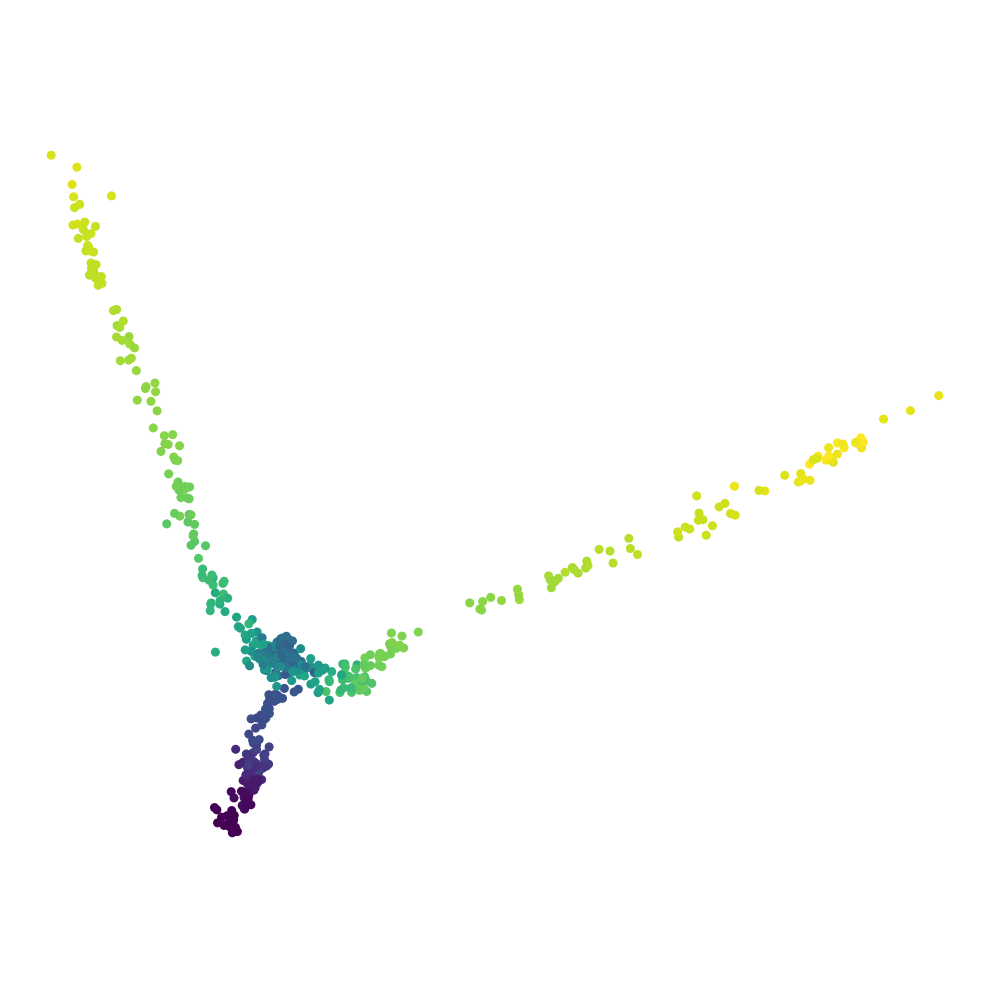

In [6]:
viridis = plt.colormaps['viridis']

fig = plt.figure(figsize=(10, 10))
#plt.quiver(expressions_2d[:, 0], expressions_2d[:, 1], velocities_2d[:, 0], velocities_2d[:, 1], color='k', scale=100., width=.002)
plt.scatter(expressions_2d[:, 0], expressions_2d[:, 1], color=viridis(pseudotime), s=30, zorder=1)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()
#plt.savefig(f'./Figures/{data_name}_pseudotime_{dimred.__class__.__name__}.svg', format='svg')
#plt.savefig(f'./Figures/{data_name}_pseudotime_{dimred.__class__.__name__}.pdf', format='pdf')

# Run CellPath

In [7]:
import cellpath as cp
from anndata import AnnData
from scipy.sparse import csr_matrix

# convert to AnnData
adata = AnnData(X = csr_matrix(spliced), layers={'spliced': csr_matrix(spliced), 'unspliced': csr_matrix(unspliced), 'velocity': velocities})

cellpath_obj = cp.CellPath(adata = adata, preprocess = True)
cellpath_obj.all_in_one(flavor = "k-means", num_metacells = num_metacells, n_neighs = int(num_metacells**.5), num_trajs = n_trj, prop_insert = 0.0, seed = 0, mode = "exact")

using k-means
Meta-cell constructed, number of meta-cells: 30
Meta-cell level neighborhood graph constructed
conduct quality control
selected path (starting_ending):
start_end:  0_10 , len:  17 newly covered: 17
start_end:  16_10 , len:  17 newly covered: 1
start_end:  6_10 , len:  16 newly covered: 1
start_end:  22_10 , len:  15 newly covered: 1
Finished
Cell-level pseudo-time inferred


# Compute error in pseudotime

In [8]:
cp_paths = cellpath_obj.pseudo_order.to_numpy()

# compute pseudo-time from path-wise orderings (NaN -> 0.5)
pseudotime_cp = np.zeros_like(pseudotime)
pseudotime_cp = np.abs(np.nan_to_num(cp_paths, nan=-250).max(axis=1))
pseudotime_cp /= np.max(pseudotime_cp)
# keep NaN if cell not in any path
pseudotime_cp[~np.isfinite(cp_paths).any(axis=1)] = np.nan

# compute error
per = 0.
for p in paths:
    cells_in_path = [i for i in range(n_cells) if data['progressions']['from'][i+1] in p]

    well_ordered = 0
    for i in cells_in_path:
        for j in cells_in_path:
            if j>i and np.isfinite(pseudotime_cp[[i,j]]).all() and (pseudotime[i] <= pseudotime[j]) == (pseudotime_cp[i] <= pseudotime_cp[j]): well_ordered += 1

    per += well_ordered / (len(cells_in_path)*(len(cells_in_path)-1)/2)

print("average percentage of well-ordered cells:", per / len(paths))

average percentage of well-ordered cells: 0.4480535640817884


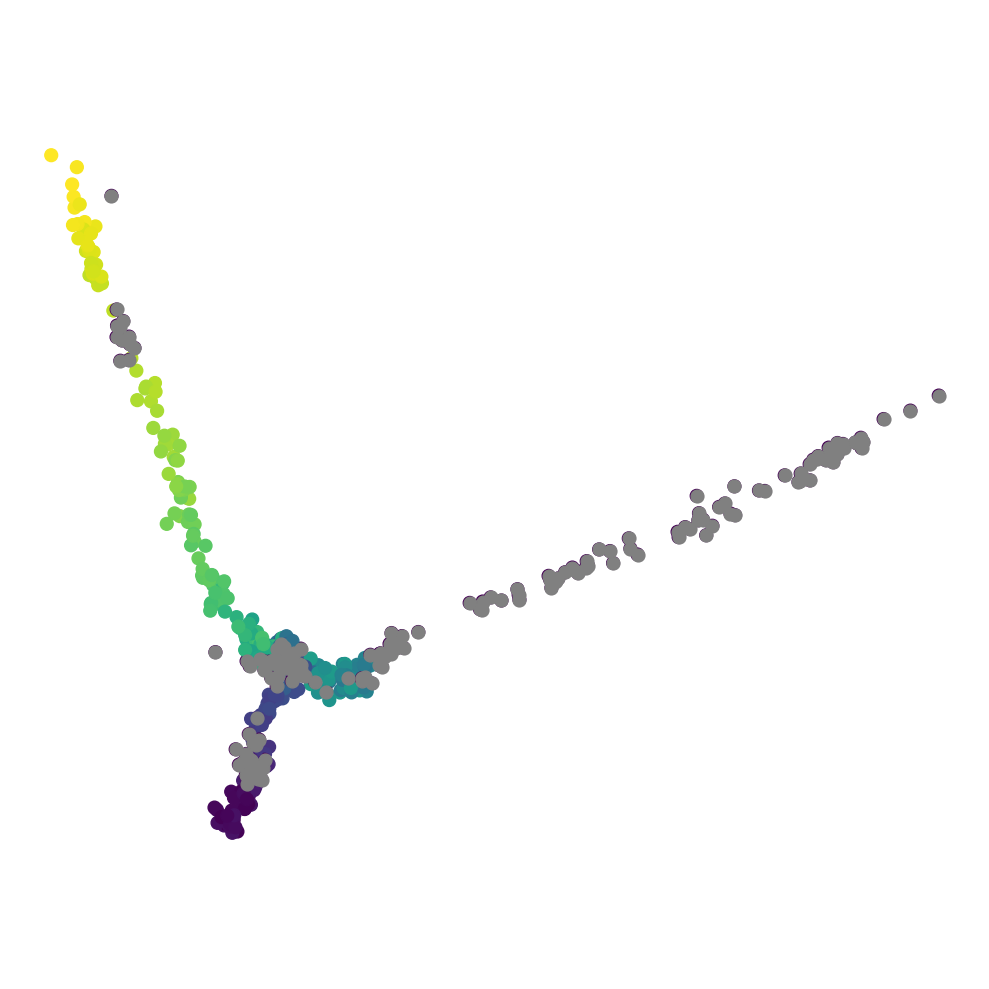

In [9]:
fig = plt.figure(figsize=(10, 10))
plt.scatter(*expressions_2d.T, color=plt.get_cmap('viridis')(np.nan_to_num(pseudotime_cp)), s=85, zorder=0)
plt.scatter(*expressions_2d[~np.isfinite(pseudotime_cp)].T, color='gray', s=85, zorder=1)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()